## Linear Regression (LR)

Linear Regression is a supervised ML algorithm that finds the best straight line to describe the relationship between an input (x) and an output (y), so you can predict y for new, unseen x values

- Supervised machine learning algorithm
- regression supervised algorithm (Works with numerical problems)
- Types: simple, multiple, polynomial LR.
- Simple: Only have one input and output column.
- Multiple: Having more then one input columns
- Polynomial:

Imagine you're trying to predict a house's price using just ONE piece of information: its size (square feet).

You look at 5 houses that already sold:

Size (sqft)    Price ($)
1000           150,000
1500           220,000
2000           290,000
2500           360,000
3000           430,000

If you plot these on a graph (size on x-axis, price on y-axis), you'd notice something: as size goes up, price goes up too, in a pretty consistent, straight-line way.

Linear Regression's entire job is this: find the best straight line that fits through these points, so you can predict the price of a NEW house you haven't seen yet, just from its size.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('placement.csv')

In [4]:
df.head(5)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package')

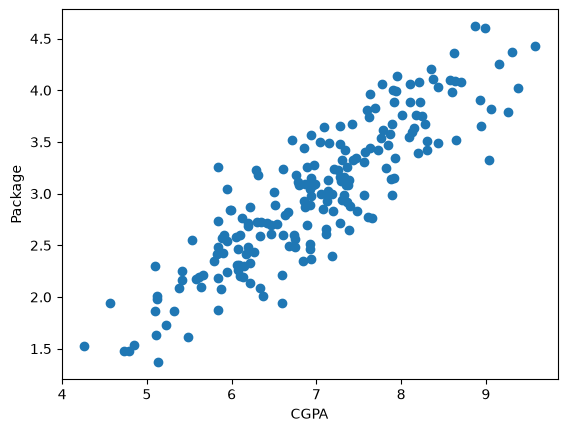

In [5]:
plt.scatter(x = df['cgpa'],y = df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package')

In [6]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.56]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.8961
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [12]:
m = lr.coef_
b = lr.intercept_

In [13]:
print(m)
print(b)

[0.55795197]
-0.8961119222429144


In [20]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

C:\Users\bilal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

In [21]:
lr.predict(x_test.iloc[1].values.reshape(1,1))

C:\Users\bilal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.09324469])

In [22]:
lr.predict(x_test.iloc[2].values.reshape(1,1))

C:\Users\bilal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.38464568])

Text(0, 0.5, 'Package')

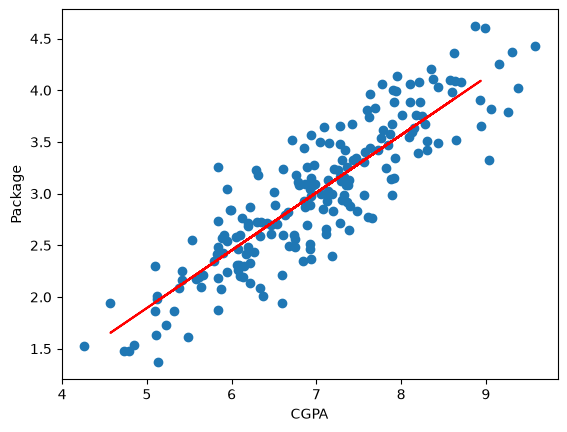

In [24]:
plt.scatter(x = df['cgpa'],y = df['package'])
plt.plot(x_test, lr.predict(x_test), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package')

In [29]:
m = lr.coef_
b = lr.intercept_

In [30]:
# y = mx + b

m*4.10+b

array([1.39149117])

In [31]:
m * 100 + b

array([54.89908542])

In [32]:
y_pred = lr.predict(x_test)

In [33]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.780730147510384